# Бинарная классификация изображений - определение генеративных и реальных изображений.

## Настройка + импорты

In [116]:
import os
import time
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms, models

CFG = {
    "data": "dataset/images",
    "real_dir": "real",
    "ai_dir": "ai",
    "img_size": 224,
    "batch_size": 32,
    "test_size": 0.15,
    "val_size": 0.15,
    "random_state": 2929,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "patience": 5,
    "epochs_cnn": 20,
    "epochs_resnet": 8,
    "tb": "tbs",
}

DATA_ROOT = Path(CFG["data"])
REAL_DIR = DATA_ROOT / CFG["real_dir"]
AI_DIR = DATA_ROOT / CFG["ai_dir"]

device = torch.device("mps" if torch.mps.is_available() else "cpu")

## EDA

Размер датасета:

In [13]:
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png"}
    files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts]
    files.sort()
    return files

real_paths = list_images(REAL_DIR)
ai_paths = list_images(AI_DIR)

print(f"real: {len(real_paths)}")
print(f"ai: {len(ai_paths)}")

real: 1999
ai: 1999


Проверка целостности изображений:

In [107]:
def filter_valid(paths):
    ok = []
    for p in paths:
        Image.open(p).convert("RGB")
        ok.append(p)
    return ok

real_ok = filter_valid(real_paths)
ai_ok = filter_valid(ai_paths)

print("valid real:", len(real_ok))
print("valid ai:", len(ai_ok))

valid real: 1999
valid ai: 1999


Пример изображений:

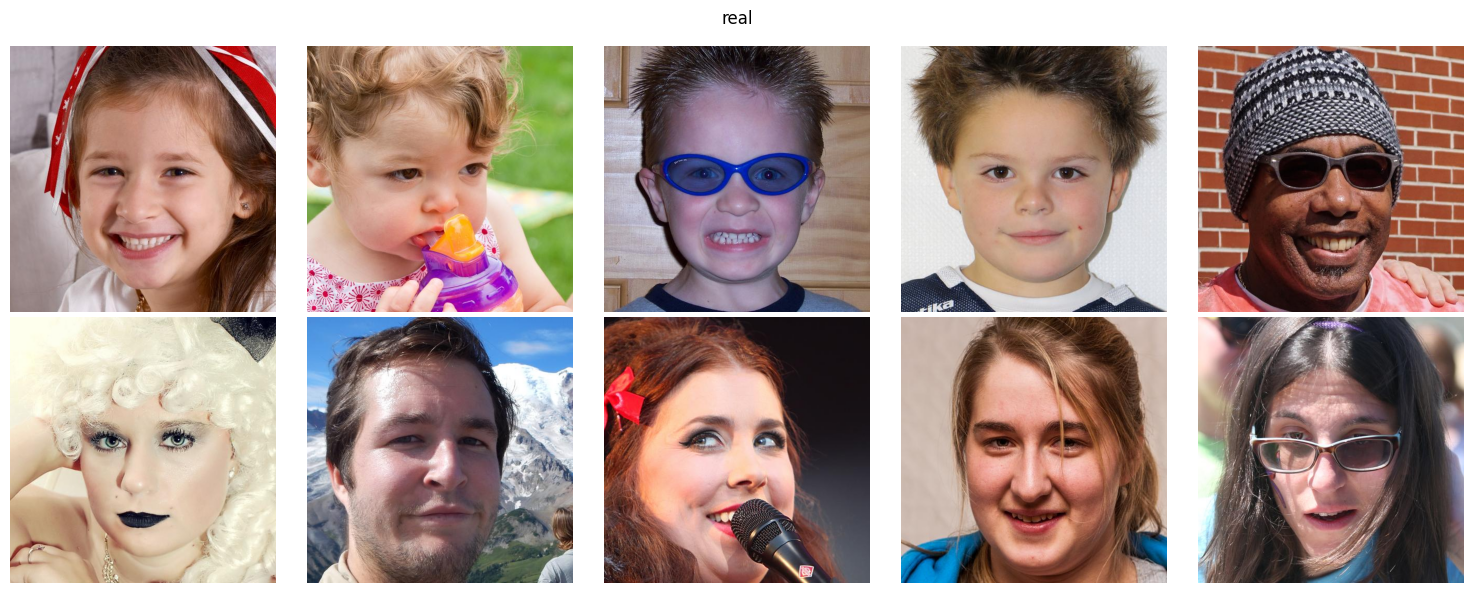

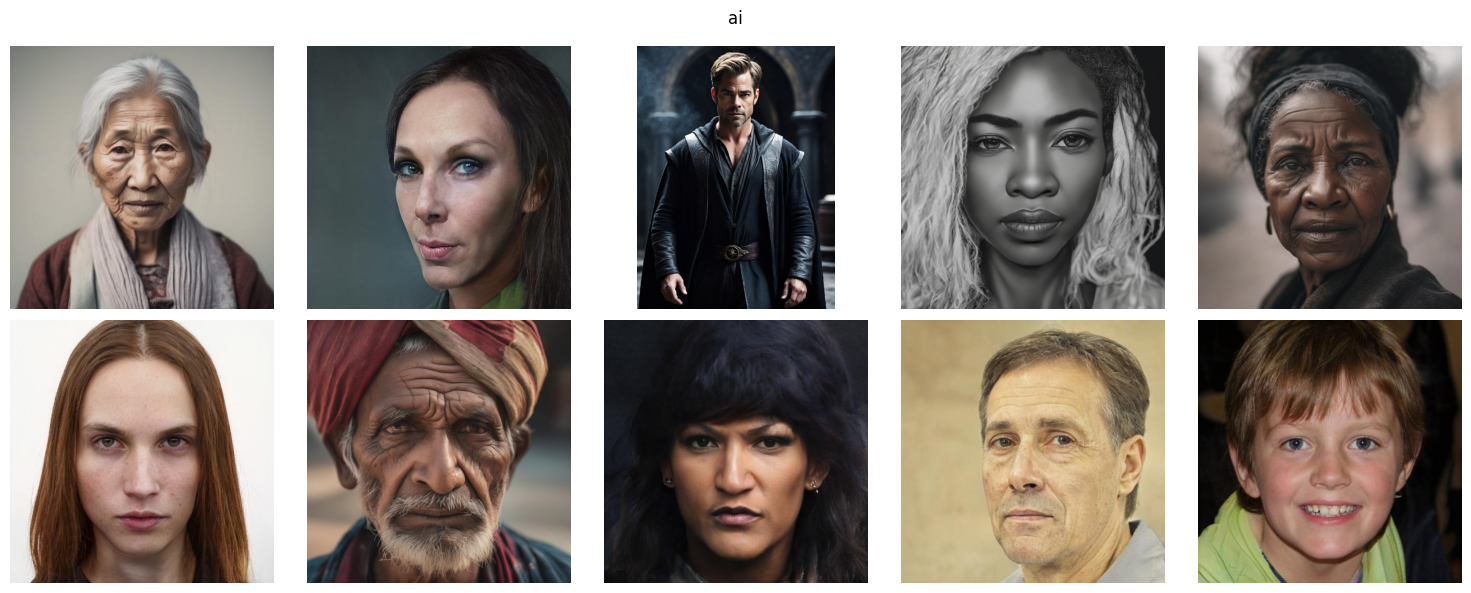

In [28]:
def show_grid(paths, title, n=10, cols=5):
    n = min(n, len(paths))
    
    idxs = np.random.choice(len(paths), size=n, replace=False)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i, idx in enumerate(idxs, start=1):
        p = paths[idx]
        img = Image.open(p).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(real_ok, "real", n=10, cols=5)
show_grid(ai_ok, "ai", n=10, cols=5)

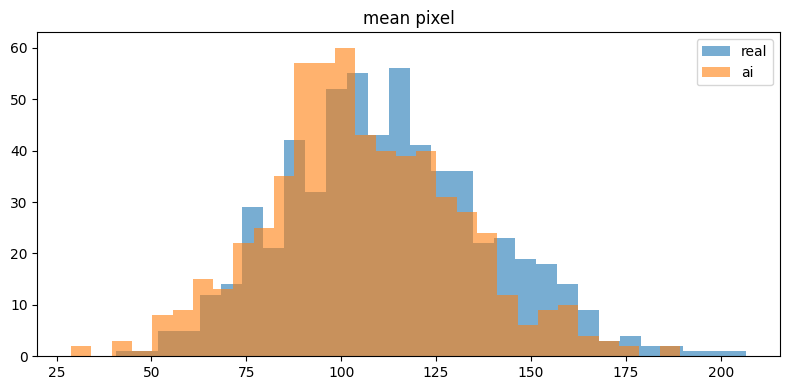

In [33]:
def brightness_scores(paths, sample_n=600):
    n = min(sample_n, len(paths))
    idxs = np.random.choice(len(paths), size=n, replace=False)

    scores = []
    for idx in idxs:
        img = Image.open(paths[idx]).convert("RGB")
        arr = np.asarray(img, dtype=np.float32)
        scores.append(float(arr.mean()))
        
    return np.array(scores)

b_real = brightness_scores(real_ok, sample_n=600)
b_ai = brightness_scores(ai_ok, sample_n=600)

plt.figure(figsize=(8, 4))
plt.hist(b_real, bins=30, alpha=0.6, label="real")
plt.hist(b_ai, bins=30, alpha=0.6, label="ai")
plt.title("mean pixel")
plt.legend()
plt.tight_layout()
plt.show()

По яркости классы разделяются плохо.

## Препроцессинг данных

Разбиение train/val/test со стратификацией:

In [44]:
X = np.array([str(p) for p in (real_ok + ai_ok)], dtype=object)
y = np.array([0] * len(real_ok) + [1] * len(ai_ok), dtype=int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=CFG["test_size"],
    random_state=CFG["random_state"],
    stratify=y,
)

val_rel = CFG["val_size"] / (1.0 - CFG["test_size"])
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_rel,
    random_state=CFG["random_state"],
    stratify=y_temp,
)

def bincount01(arr, name):
    arr = np.asarray(arr).astype(int)
    c = np.bincount(arr, minlength=2)
    print(f"{name}: total={len(arr)}, real(0)={c[0]}, ai(1)={c[1]}")

bincount01(y_train, "train")
bincount01(y_val, "val")
bincount01(y_test, "test")

train: total=2798, real(0)=1399, ai(1)=1399
val: total=600, real(0)=300, ai(1)=300
test: total=600, real(0)=300, ai(1)=300


Dataset + DataLoader + Tranforms:

In [112]:
IMG_SIZE = CFG["img_size"]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

class Dataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        y = int(self.labels[idx])

        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        return img, torch.tensor(y, dtype=torch.long)

train_ds = Dataset(X_train, y_train, transform=train_tfms)
val_ds = Dataset(X_val, y_val, transform=eval_tfms)
test_ds = Dataset(X_test, y_test, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False)

## CNN

Реализация:

In [48]:
class CNN(nn.Module):
    def __init__(self, num_classes=2, emb_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
        )
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        emb = self.embedding(x)
        logits = self.classifier(emb)
        return logits

    @torch.no_grad()
    def forward_embeddings(self, x):
        x = self.features(x)
        emb = self.embedding(x)
        return emb

Обучение с batchnorm + dropout + early stopping, чтобы снизить переобучение:

In [117]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_y, all_pred = [], []
    total_loss, total_n = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        pred = logits.argmax(dim=1)
        bs = yb.size(0)
        total_loss += float(loss.item()) * bs
        total_n += bs

        all_y.append(yb.cpu())
        all_pred.append(pred.cpu())

    all_y = torch.cat(all_y).numpy()
    all_pred = torch.cat(all_pred).numpy()

    acc = accuracy_score(all_y, all_pred)
    p, r, f1, _ = precision_recall_fscore_support(all_y, all_pred, average="binary", zero_division=0)

    return {
        "loss": total_loss / max(total_n, 1),
        "acc": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_n = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        bs = yb.size(0)
        total_loss += float(loss.item()) * bs
        total_n += bs

    return (total_loss / max(total_n, 1))

def fit(model, train_loader, val_loader, epochs, lr, tag, writer):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=lr, weight_decay=CFG["weight_decay"])

    best_f1 = -1.0
    best_state = None
    no_improve = 0

    print(f"\n[{tag}] start: epochs={epochs}, lr={lr}, trainable_params={sum(p.numel() for p in params):}")

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        train_m = evaluate(model, train_loader)
        val_m = evaluate(model, val_loader)

        if writer is not None:
            writer.add_scalar("loss/train", train_loss, epoch)
            writer.add_scalar("loss/val", val_m["loss"], epoch)
            writer.add_scalar("f1/train", train_m["f1"], epoch)
            writer.add_scalar("f1/val", val_m["f1"], epoch)
            writer.add_scalar("acc/val", val_m["acc"], epoch)

        print(f"[{tag}] epoch {epoch:02d} | train_loss={train_loss:.3f} | val_loss={val_m['loss']:.3f} | val_f1={val_m['f1']:.3f}")

        if val_m["f1"] > best_f1 + 1e-4:
            best_f1 = val_m["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"[{tag}] best_val_f1={best_f1:.3f}")
    
    return {"best_val_f1": best_f1}

cnn = CNN(num_classes=2).to(device)
writer_cnn = SummaryWriter(log_dir=str(Path(CFG["tb"]) / "cnn"))

cnn_fit_info = fit(
    cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CFG["epochs_cnn"],
    lr=CFG["lr"],
    tag="cnn",
    writer=writer_cnn,
)

writer_cnn.close()


[cnn] start: epochs=20, lr=0.001, trainable_params=422530
[cnn] epoch 01 | train_loss=0.533 | val_loss=0.527 | val_f1=0.655
[cnn] epoch 02 | train_loss=0.497 | val_loss=0.459 | val_f1=0.749
[cnn] epoch 03 | train_loss=0.476 | val_loss=0.434 | val_f1=0.744
[cnn] epoch 04 | train_loss=0.467 | val_loss=0.423 | val_f1=0.803
[cnn] epoch 05 | train_loss=0.453 | val_loss=0.410 | val_f1=0.800
[cnn] epoch 06 | train_loss=0.463 | val_loss=0.419 | val_f1=0.757
[cnn] epoch 07 | train_loss=0.430 | val_loss=0.408 | val_f1=0.806
[cnn] epoch 08 | train_loss=0.428 | val_loss=0.400 | val_f1=0.810
[cnn] epoch 09 | train_loss=0.424 | val_loss=0.429 | val_f1=0.740
[cnn] epoch 10 | train_loss=0.418 | val_loss=0.466 | val_f1=0.807
[cnn] epoch 11 | train_loss=0.416 | val_loss=0.466 | val_f1=0.807
[cnn] epoch 12 | train_loss=0.411 | val_loss=0.408 | val_f1=0.780
[cnn] epoch 13 | train_loss=0.433 | val_loss=0.410 | val_f1=0.751
[cnn] best_val_f1=0.810


Итоговые метрики на test:

In [118]:
cnn_test = evaluate(cnn, test_loader)

@torch.no_grad()
def predict_labels(model, loader):
    model.eval()
    ys, preds = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(yb.numpy())
        preds.append(pred)
        
    return np.concatenate(ys), np.concatenate(preds)

y_true, y_pred = predict_labels(cnn, test_loader)
print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=3))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)


Classification report:
              precision    recall  f1-score   support

           0      0.843     0.823     0.833       300
           1      0.827     0.847     0.837       300

    accuracy                          0.835       600
   macro avg      0.835     0.835     0.835       600
weighted avg      0.835     0.835     0.835       600

Confusion matrix:
 [[247  53]
 [ 46 254]]


Модель лучше распознаёт класс ai, чем класс real. Из confusion matrix видно, что ошибок вида "real - ai" больше, чем "ai - real".
По графикам tensorboard видно, что обучение стабильно (train loss убывает, val loss в среднем тоже). Метрики на val быстро растут в первые эпохи и достигают лучшего значения примерно на 7 эпохе, после чего наблюдается снижение, скорее всего из-за начала переобучения.

## Эмбеддинги + t-SNE

Эмбеддинги берём из предпоследнего линейного слоя и уменьшаем размерность до 2D с помощью t-SNE, и раскрашиваем по таргетному классу.

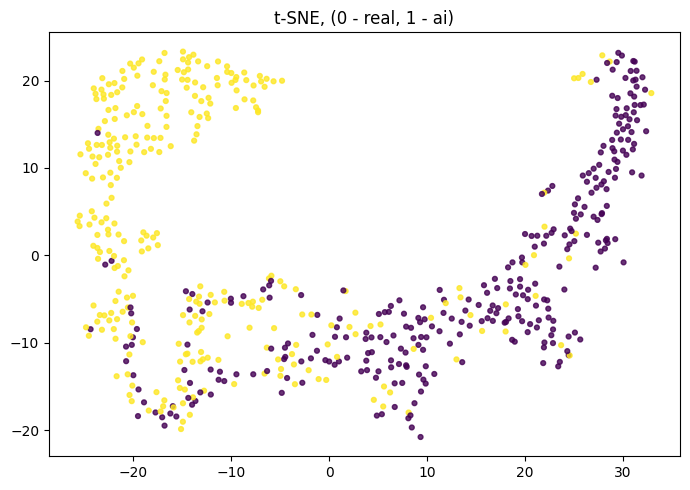

In [119]:
@torch.no_grad()
def extract_embeddings(model: CNN, loader, max_items=2000):
    model.eval()
    embs, ys = [], []
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        emb = model.forward_embeddings(xb).cpu().numpy()

        embs.append(emb)
        ys.append(yb.numpy())
        total += len(yb)

        if total >= max_items:
            break

    embs = np.vstack(embs)[:max_items]
    ys = np.concatenate(ys)[:max_items]
    return embs, ys

embs, y_emb = extract_embeddings(cnn, test_loader, max_items=2000)

tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=CFG["random_state"])
emb_2d = tsne.fit_transform(embs)

plt.figure(figsize=(7, 5))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=y_emb, s=12, alpha=0.8)
plt.title("t-SNE, (0 - real, 1 - ai)")
plt.tight_layout()
plt.show()

t-SNE по эмбеддингам показывает заметное разделение классов, но присутствует смешивание. Часть изображений имеет похожие признаки в обоих классах.

## ResNet

Реализация:

In [91]:
def resnet18_transfer(num_classes=2):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.1),
        nn.Linear(in_features, num_classes))
    
    return model

Freeze/unfreez:

In [81]:
def freeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True

Обучение:

In [92]:
resnet = resnet18_transfer(num_classes=2).to(device)
freeze_backbone(resnet)

writer_resnet = SummaryWriter(log_dir=str(Path(CFG["tb"]) / "resnet18"))

resnet_fit_info = fit(
    resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CFG["epochs_resnet"],
    lr=CFG["lr"],
    tag="resnet18",
    writer=writer_resnet,
)

writer_resnet.close()


[resnet18] start: epochs=8, lr=0.001, trainable_params=1,026
[resnet18] epoch 01 | train_loss=0.475 | val_loss=0.379 | val_f1=0.818
[resnet18] epoch 02 | train_loss=0.397 | val_loss=0.339 | val_f1=0.844
[resnet18] epoch 03 | train_loss=0.365 | val_loss=0.320 | val_f1=0.844
[resnet18] epoch 04 | train_loss=0.360 | val_loss=0.337 | val_f1=0.857
[resnet18] epoch 05 | train_loss=0.349 | val_loss=0.346 | val_f1=0.857
[resnet18] epoch 06 | train_loss=0.336 | val_loss=0.343 | val_f1=0.837
[resnet18] epoch 07 | train_loss=0.330 | val_loss=0.305 | val_f1=0.855
[resnet18] epoch 08 | train_loss=0.318 | val_loss=0.304 | val_f1=0.861
[resnet18] done: best_val_f1=0.861


Итоговые метрики на test:

In [93]:
resnet_test = evaluate(resnet, test_loader)

y_true_r, y_pred_r = predict_labels(resnet, test_loader)
print("\nClassification report:")
print(classification_report(y_true_r, y_pred_r, digits=3))

cm_r = confusion_matrix(y_true_r, y_pred_r)
print("Confusion matrix:\n", cm_r)


Classification report:
              precision    recall  f1-score   support

           0      0.880     0.907     0.893       300
           1      0.904     0.877     0.890       300

    accuracy                          0.892       600
   macro avg      0.892     0.892     0.892       600
weighted avg      0.892     0.892     0.892       600

Confusion matrix:
 [[272  28]
 [ 37 263]]


Здесь по графикам tensorboard видно, что resnet обучается стабильнее, чем CNN.

## Сравнение CNN и ResNet

Сравним метрики на test и длительность обучения.

In [135]:
print(df_cmp)

    model  test_acc   test_f1  best_val_f1
1  resnet  0.891667  0.890017     0.861386
0     cnn  0.826667  0.838006     0.832258


CNN с нуля сильнее рискует переобучиться, а ResNet даёт более стабильные метрики при меньшем числе эпох.